# 7.6: Batch Simulation with Dask

This example shows how to do batch simulations in HNN-core using the [Dask library](https://docs.dask.org/en/stable/index.html). This allows users to
efficiently run multiple simulations with different parameters for comprehensive analysis, potentially across multiple machines, using the Dask framework.

Authors: 

- Abdul Samad Siddiqui ( abdulsamadsid1@gmail.com )
- Nick Tolley ( nicholas_tolley@brown.edu )
- Ryan Thorpe ( ryan_thorpe@brown.edu )
- Mainak Jas ( mjas@mgh.harvard.edu )
- M Yaswanth Reddy ( [https://github.com/Yaswanth8390](https://github.com/Yaswanth8390) )

This project was supported by Google Summer of Code (GSoC) 2024.

## 1. Import Dask dependencies

**Please note that in order to run this tutorial you MUST have installed the "dask" dependencies for HNN-Core. Normally, these are optional for general HNN-Core use, but they are required for this tutorial. In the next cell, we will check to make sure they are installed, and if they are not, then please follow the directions provided.**


In [1]:
try:
    from hnn_core.batch_simulate import BatchSimulate
    from dask.distributed import Client, LocalCluster
except ModuleNotFoundError:
    raise ModuleNotFoundError("""
The "dask[distributed]" module required for using Dask is not available. Please install the hnn-core package using

    pip install "hnn-core[dask]"

""")

If you installed `hnn_core` using the Python or Conda package (i.e. not from source), then you can **uncomment and run** the following code cell to easily install the optimization dependences into your current Python environment. If you do so, please restart your Jupyter kernel before running the notebook again.

In [2]:
# %pip install -q "hnn-core[dask]"

## 2. Import remaining libraries

Next, let's import the other `hnn_core` modules and external libraries required for this tutorial.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import psutil  # installed via "hnn-core[dask]" above

from hnn_core import neymotin_2020_model

# This uses the total number of CPU cores on your machine minus one:
n_jobs = psutil.cpu_count(logical=False) - 1

The `add_evoked_drive` function simulates external input to the network,
mimicking sensory stimulation or other external events.

- `evprox` indicates a proximal drive, targeting dendrites near the cell
  bodies.
- `mu=40` and `sigma=5` define the timing (mean and spread) of the input.
- `weights_ampa` and `synaptic_delays` control the strength and
  timing of the input.

This evoked drive causes the initial positive deflection in the dipole
signal, triggering a cascade of activity through the network and
resulting in the complex waveforms observed.



In [4]:
def set_params(net, param_values):
    """
    Set parameters for the network drives.

    Parameters
    ----------
    net : instance of Network
        The network to modify.
    param_values : dict
        Dictionary of parameter values.
    """
    weights_ampa = {'L2_basket': param_values['weight_basket'],
                    'L2_pyramidal': param_values['weight_pyr'],
                    'L5_basket': param_values['weight_basket'],
                    'L5_pyramidal': param_values['weight_pyr']}

    synaptic_delays = {'L2_basket': 0.1, 'L2_pyramidal': 0.1,
                       'L5_basket': 1., 'L5_pyramidal': 1.}

    # Add an evoked drive to the network.
    net.add_evoked_drive('evprox',
                         mu=40,
                         sigma=5,
                         numspikes=1,
                         location='proximal',
                         weights_ampa=weights_ampa,
                         synaptic_delays=synaptic_delays)

Next, we define a parameter grid for the batch simulation.



In [5]:
param_grid = {
    'weight_basket': np.logspace(-4, -1, 20),
    'weight_pyr': np.logspace(-4, -1, 20)
}

We then define a function to calculate summary statistics.



In [6]:
def summary_func(results):
    """
    Calculate the min and max dipole peak for each simulation result.

    Parameters
    ----------
    results : list
        List of dictionaries containing simulation results.

    Returns
    -------
    summary_stats : list
        Summary statistics for each simulation result.
    """
    summary_stats = []
    for result in results:
        dpl_smooth = result['dpl'][0].copy().smooth(window_len=30)
        dpl_data = dpl_smooth.data['agg']
        min_peak = np.min(dpl_data)
        max_peak = np.max(dpl_data)
        summary_stats.append({'min_peak': min_peak, 'max_peak': max_peak})
    return summary_stats

Setup the network that we will use for simulation.


In [7]:
net = neymotin_2020_model(mesh_shape=(3, 3))

Dask can be used as a backend for distributed computing.
For local use, `LocalCluster` can be used as shown below.
Note that `threads_per_worker=1` is required to avoid NEURON conflicts.
To run on a remote cluster instead, replace `LocalCluster` with a
`Client` connected to your cluster scheduler address e.g.
"Client('mycluster.university.edu:8786')".

In [8]:
batch_simulation = BatchSimulate(net=net,
                                 set_params=set_params,
                                 summary_func=summary_func)
cluster = LocalCluster(processes=True, n_workers=n_jobs, threads_per_worker=1)
client = Client(cluster)
simulation_results = batch_simulation.run(
    param_grid, n_jobs=n_jobs, combinations=False, backend="dask"
)
print("Simulation results:", simulation_results)
client.close()

Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
B

This plot shows an overlay of all smoothed dipole waveforms from the
batch simulation. Each line represents a different set of synaptic strength
parameters (`weight_basket`), allowing us to visualize the range of responses
across the parameter space.
The colormap represents synaptic strengths, from weaker (purple)
to stronger (yellow).

As drive strength increases, dipole responses show progressively larger
amplitudes and more distinct features, reflecting heightened network
activity. Weak drives (purple lines) produce smaller amplitude signals with
simpler waveforms, while stronger drives (yellow lines) generate
larger responses with more pronounced oscillatory features, indicating
more robust network activity.

The y-axis represents dipole amplitude in `nAm` (nanoAmpere-meters), which is
the product of current flow and distance in the neural tissue.

Stronger synaptic connections (yellow lines) generally show larger
amplitude responses and more pronounced features throughout the simulation.



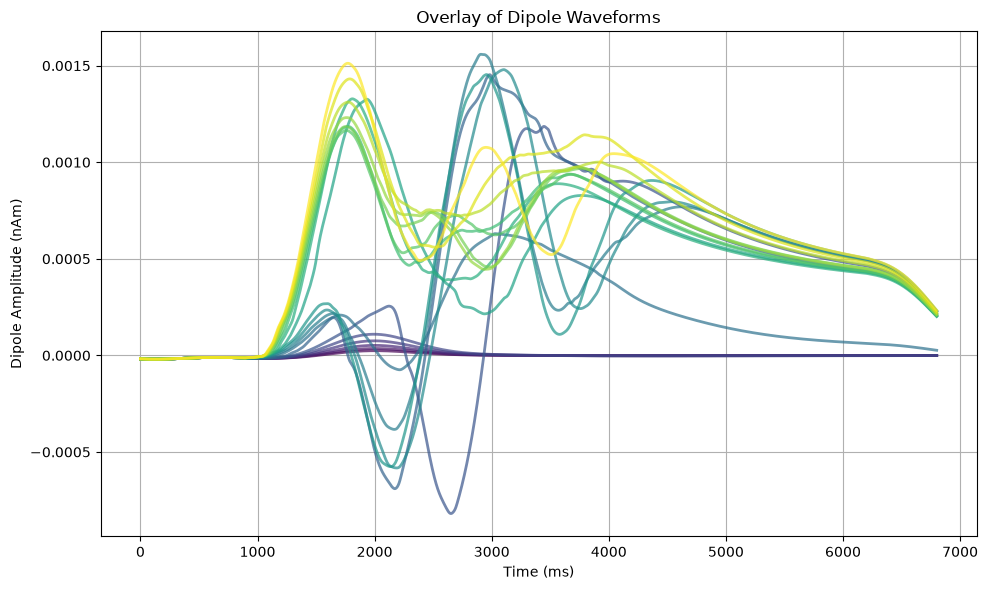

In [9]:
dpl_waveforms, param_values = [], []
for data_list in simulation_results['simulated_data']:
    for data in data_list:
        dpl_smooth = data['dpl'][0].copy().smooth(window_len=30)
        dpl_waveforms.append(dpl_smooth.data['agg'])
        param_values.append(data['param_values']['weight_basket'])

plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('viridis')
log_param_values = np.log10(param_values)
norm = plt.Normalize(log_param_values.min(), log_param_values.max())

for waveform, log_param in zip(dpl_waveforms, log_param_values):
    color = cmap(norm(log_param))
    plt.plot(waveform, color=color, alpha=0.7, linewidth=2)
plt.title('Overlay of Dipole Waveforms')
plt.xlabel('Time (ms)')
plt.ylabel('Dipole Amplitude (nAm)')
plt.grid(True)
plt.tight_layout()
plt.show()

This plot displays the minimum and maximum dipole peaks across
different synaptic strengths. This allows us to see how the range of
dipole activity changes as we vary the synaptic strength parameter.



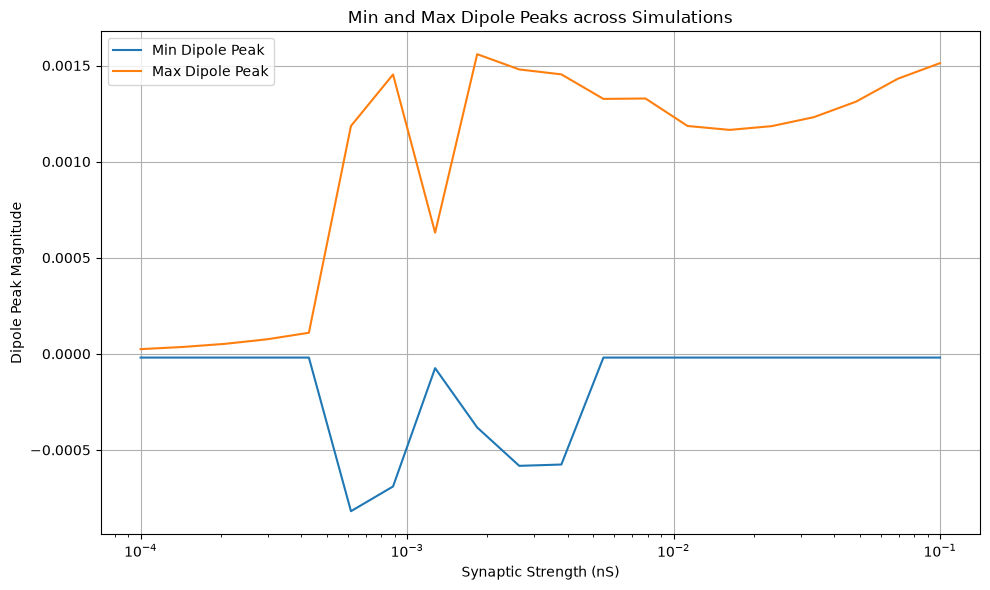

In [10]:
min_peaks, max_peaks, param_values = [], [], []
for summary_list, data_list in zip(simulation_results['summary_statistics'],
                                   simulation_results['simulated_data']):
    for summary, data in zip(summary_list, data_list):
        min_peaks.append(summary['min_peak'])
        max_peaks.append(summary['max_peak'])
        param_values.append(data['param_values']['weight_basket'])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(param_values, min_peaks, label='Min Dipole Peak')
plt.plot(param_values, max_peaks, label='Max Dipole Peak')
plt.xlabel('Synaptic Strength (nS)')
plt.ylabel('Dipole Peak Magnitude')
plt.title('Min and Max Dipole Peaks across Simulations')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.tight_layout()
plt.show()